# Publication Figures — Main Manuscript

This notebook generates all main figures  by calling functions
from `generate_main_figures.py`.

## Experiment Structure

- **Experiment 1 = Dynamic Coherence** (`../experiment1/E1.pkl`)  
  Ramped motion coherence (30 % or 70 %) varied trial-by-trial.  
  Coherence level creates within-trial uncertainty variation.

- **Experiment 2 = Fixed Coherence** (`../experiment2/E2.pkl`)  
  Constant coherence within each trial (30 % or 70 %), randomly interleaved.

## Figures generated

| Figure | Description |
|--------|-------------|
| Fig 2  | Central Tendency — both experiments |
| Fig 3  | Serial Dependence — 4-panel |
| Fig 4  | Sanity Check — n-3 to n+2 lags |
| Fig 5  | Cross-Experiment Comparison |
| Fig C1 | Model Comparison (requires Kalman model output) |
| Fig 7  | Best-Model Parameters (requires Kalman model output) |
| Fig C2 | CTI / SDI Recovery (requires Kalman model output) |
| Fig 8  | Trial-Level Serial Dependence — model vs. data (requires Kalman model output) |

## Imports

In [11]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Make sure the combined/ directory is importable
COMBINED_DIR = Path.cwd()  # notebook runs from analysis/combined/
if str(COMBINED_DIR) not in sys.path:
    sys.path.insert(0, str(COMBINED_DIR))

# Also add shared/ to path (generate_main_figures already does this, but be explicit)
SHARED_DIR = COMBINED_DIR / '..' / '..' / 'shared'
if str(SHARED_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SHARED_DIR.resolve()))

# Inline figure display at retina resolution
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print('Python:', sys.version)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('Matplotlib:', matplotlib.__version__)

Python: 3.13.11 (main, Jan 14 2026, 23:14:53) [Clang 21.1.4 ]
NumPy: 2.4.0
Pandas: 2.3.3
Matplotlib: 3.10.8


## Import figure-generation module

In [12]:
import generate_main_figures as gmf

print('Loaded generate_main_figures.py')
print('Output directory:', gmf.FIG_DIR.resolve())

Loaded generate_main_figures.py
Output directory: /Users/chunyu/Documents/GitHub/precision-weighting-serial-dependence/manuscript/figures


## Load Data

Data are loaded from:
- `../experiment1/E1.pkl`  — Experiment 1, Dynamic Coherence
- `../experiment2/E2.pkl`  — Experiment 2, Fixed Coherence

Outlier trials are excluded, grouping variables added, and ResponseType computed.

In [13]:
df1, df2 = gmf.load_data()

Experiment 1 (Dynamic Coherence): 4670 trials, 22 subjects
Experiment 2 (Fixed Coherence):   4638 trials, 22 subjects


## Compute SDI and CTI

In [14]:
df_sdi_1, df_sdi_2 = gmf.compute_sdi_dataframes(df1, df2)
df_cti_1, df_cti_2 = gmf.compute_cti_dataframes(df1, df2)

Exp 1 SDI: 88 observations
Exp 2 SDI: 88 observations
CTI computed for supplementary figures (absolute values)


---
## Figure 2: Central Tendency

Saved fig2_central_tendency


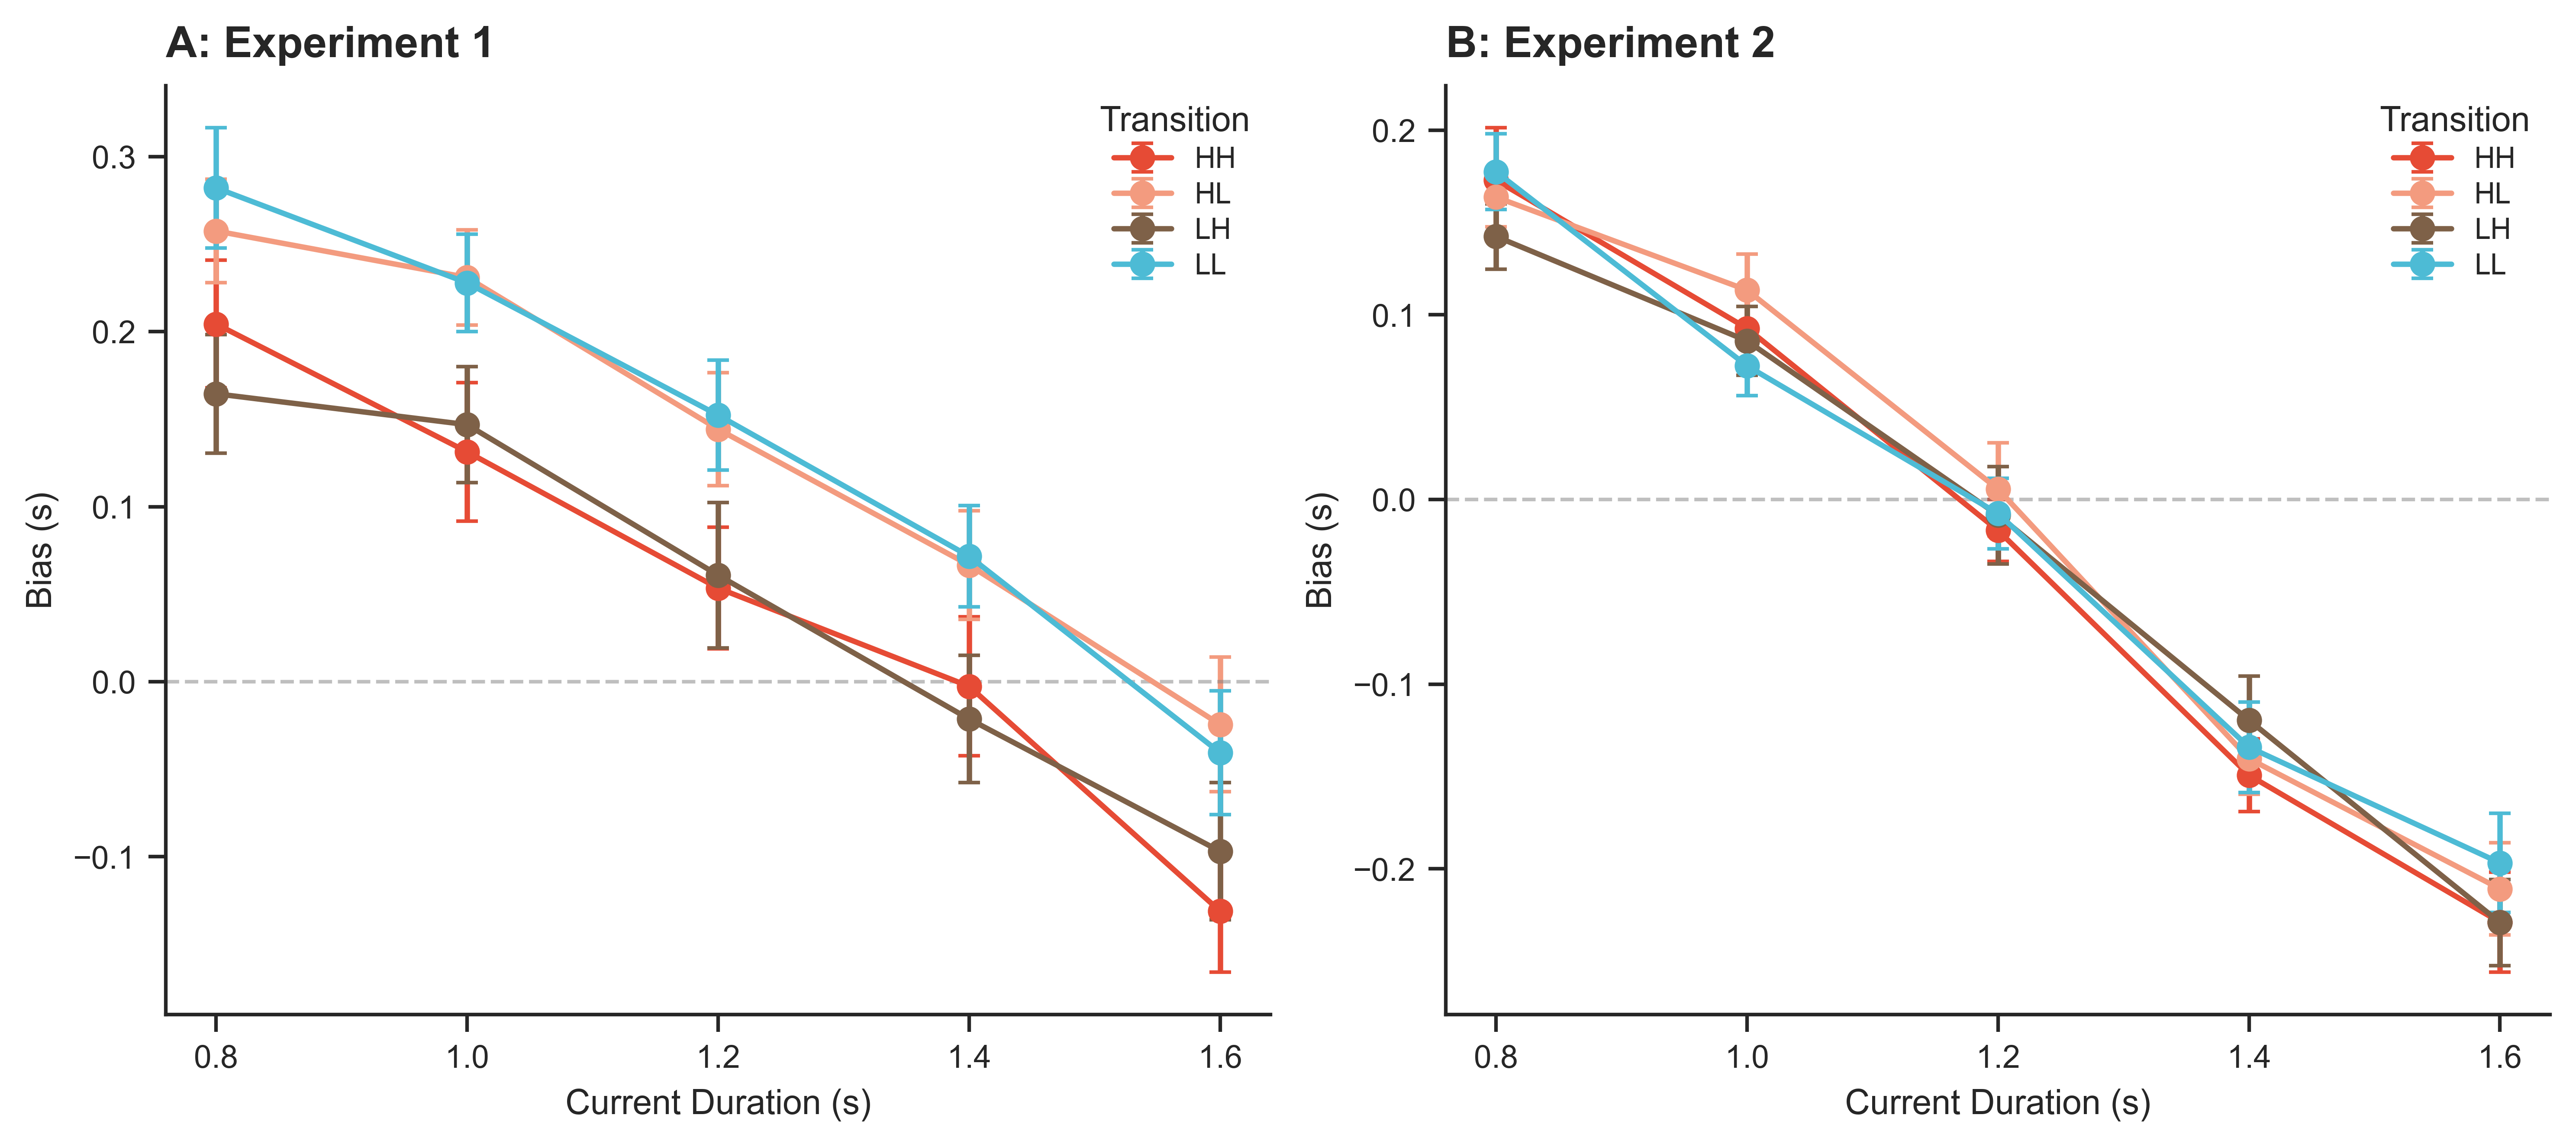

In [15]:
gmf.plot_fig2_central_tendency(df1, df2)
plt.show()

---
## Figure 3: Serial Dependence

Saved fig3_serial_dependence


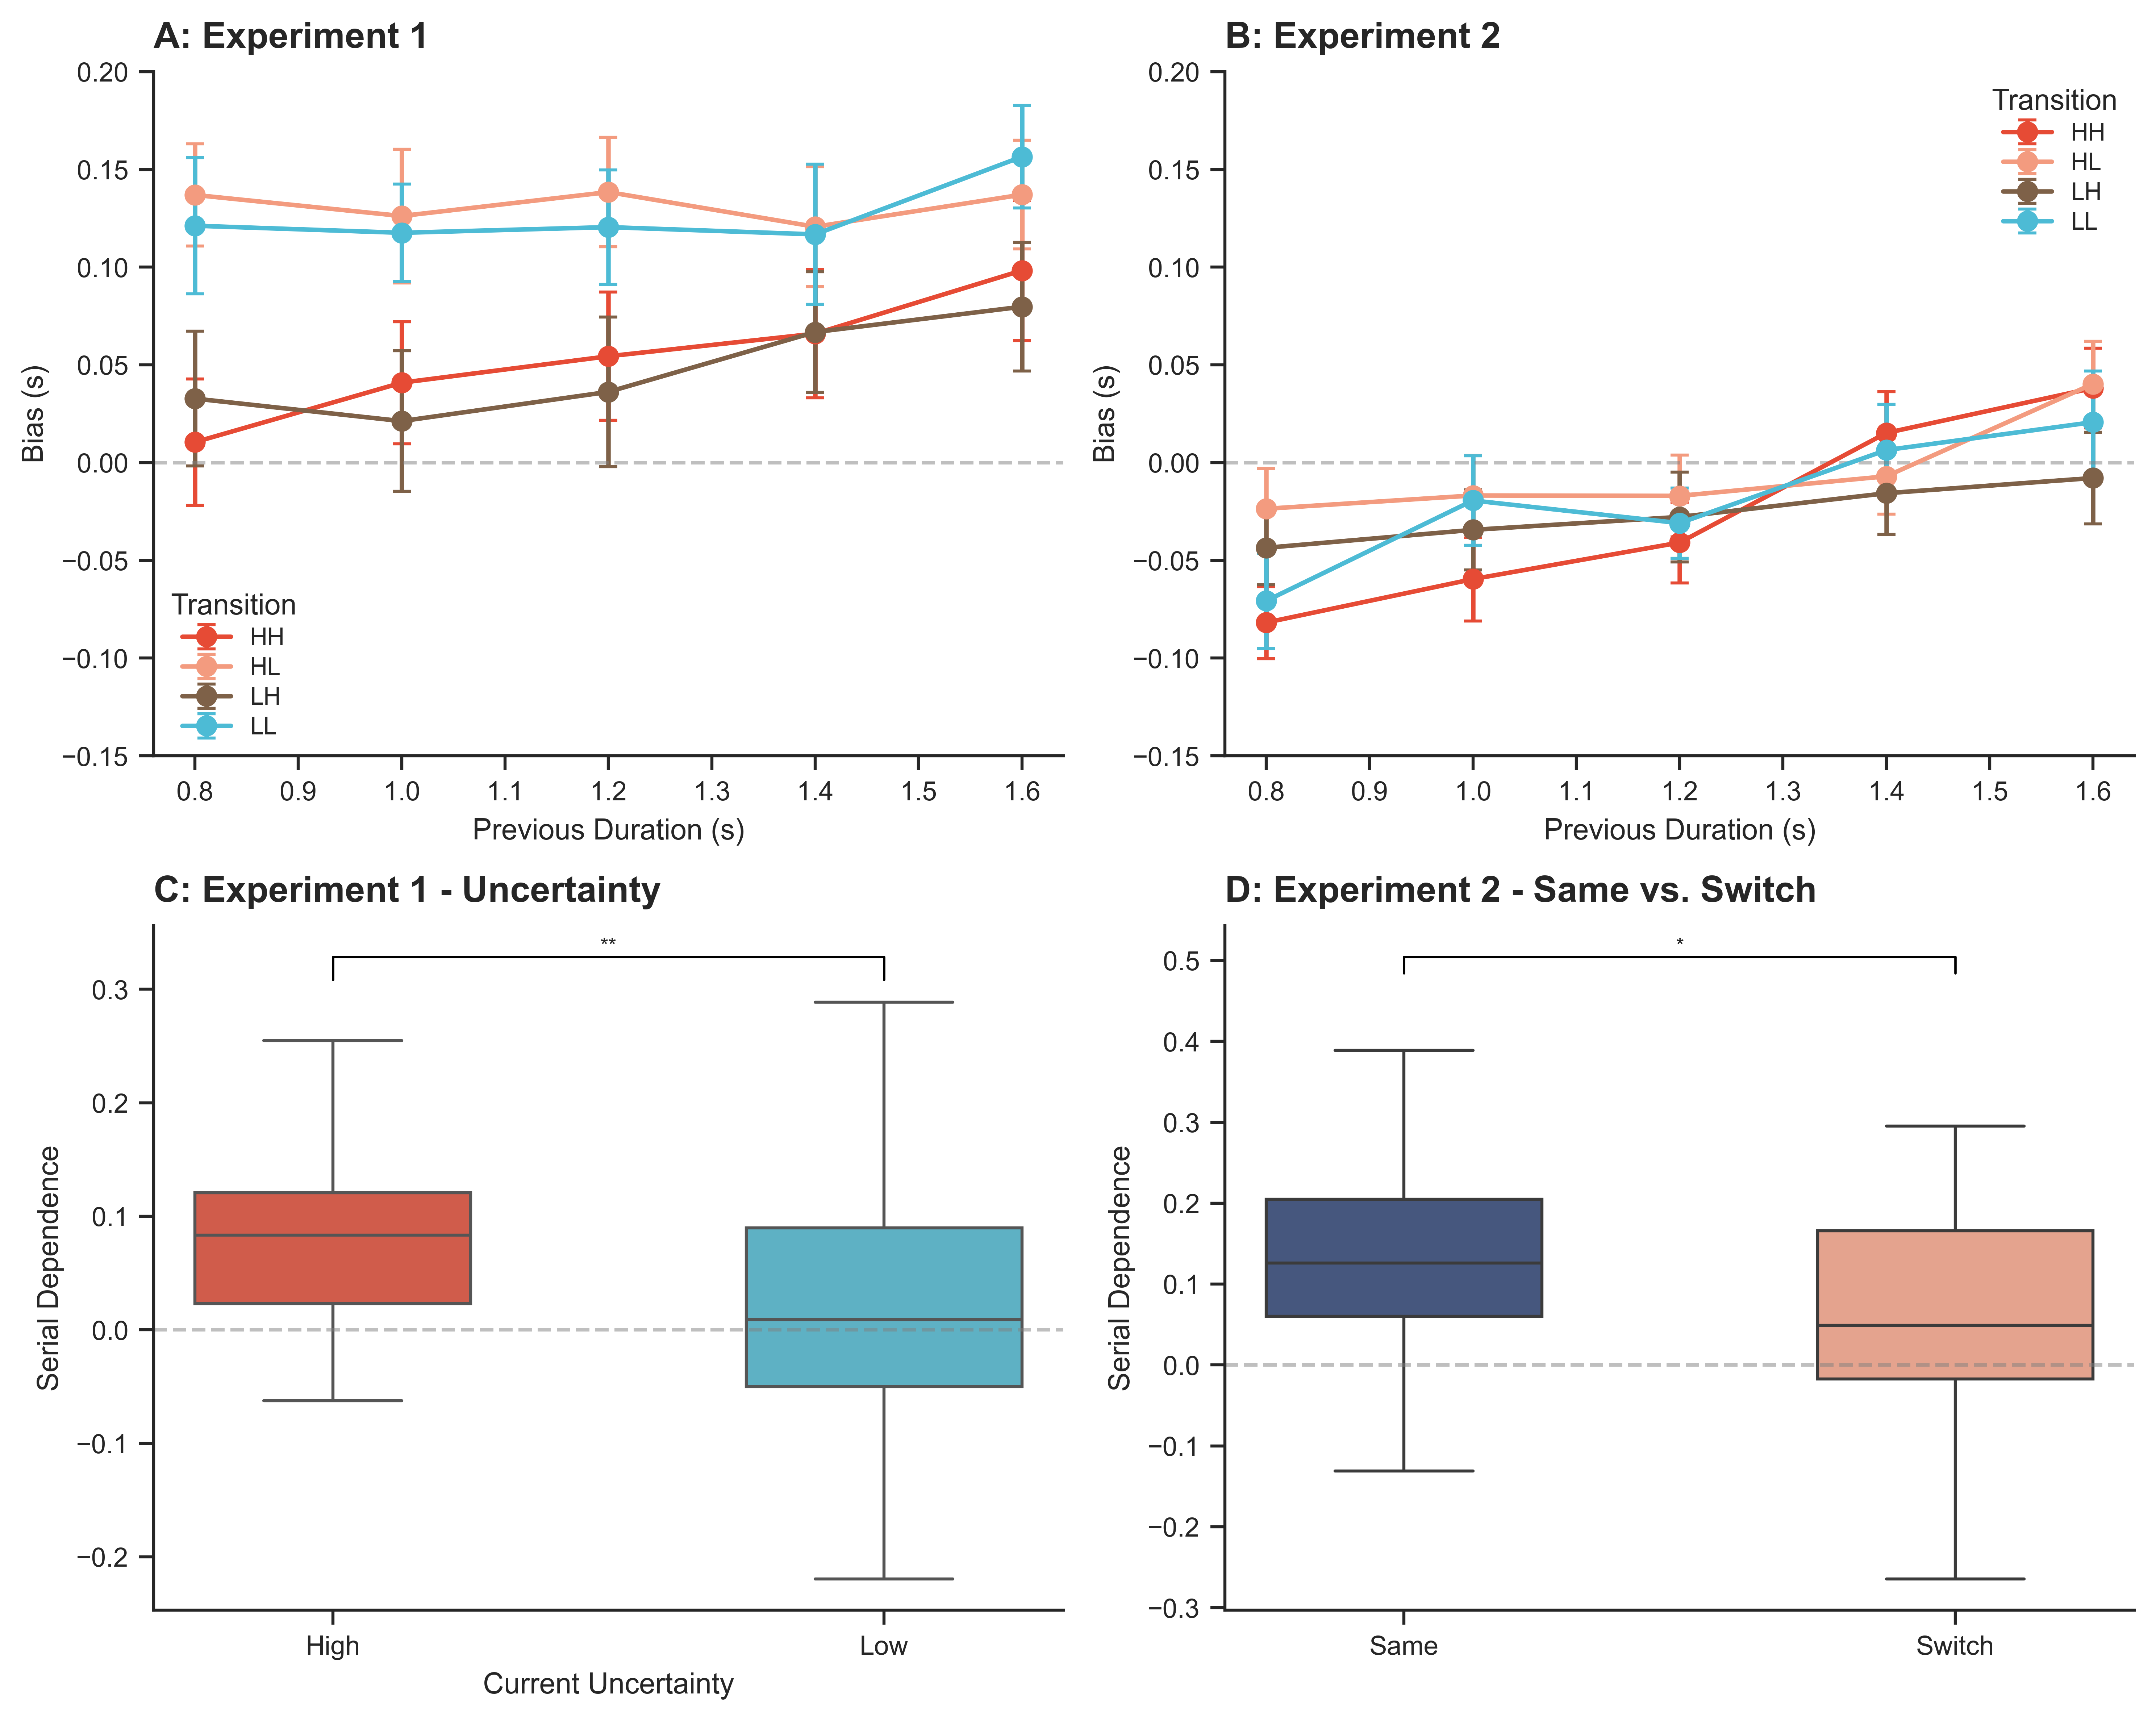

In [16]:
gmf.plot_fig3_serial_dependence(df1, df2, df_sdi_1, df_sdi_2)
plt.show()

---
## Figure 4: Sanity Check (n-3 to n+2)

Saved fig4_sanity_check


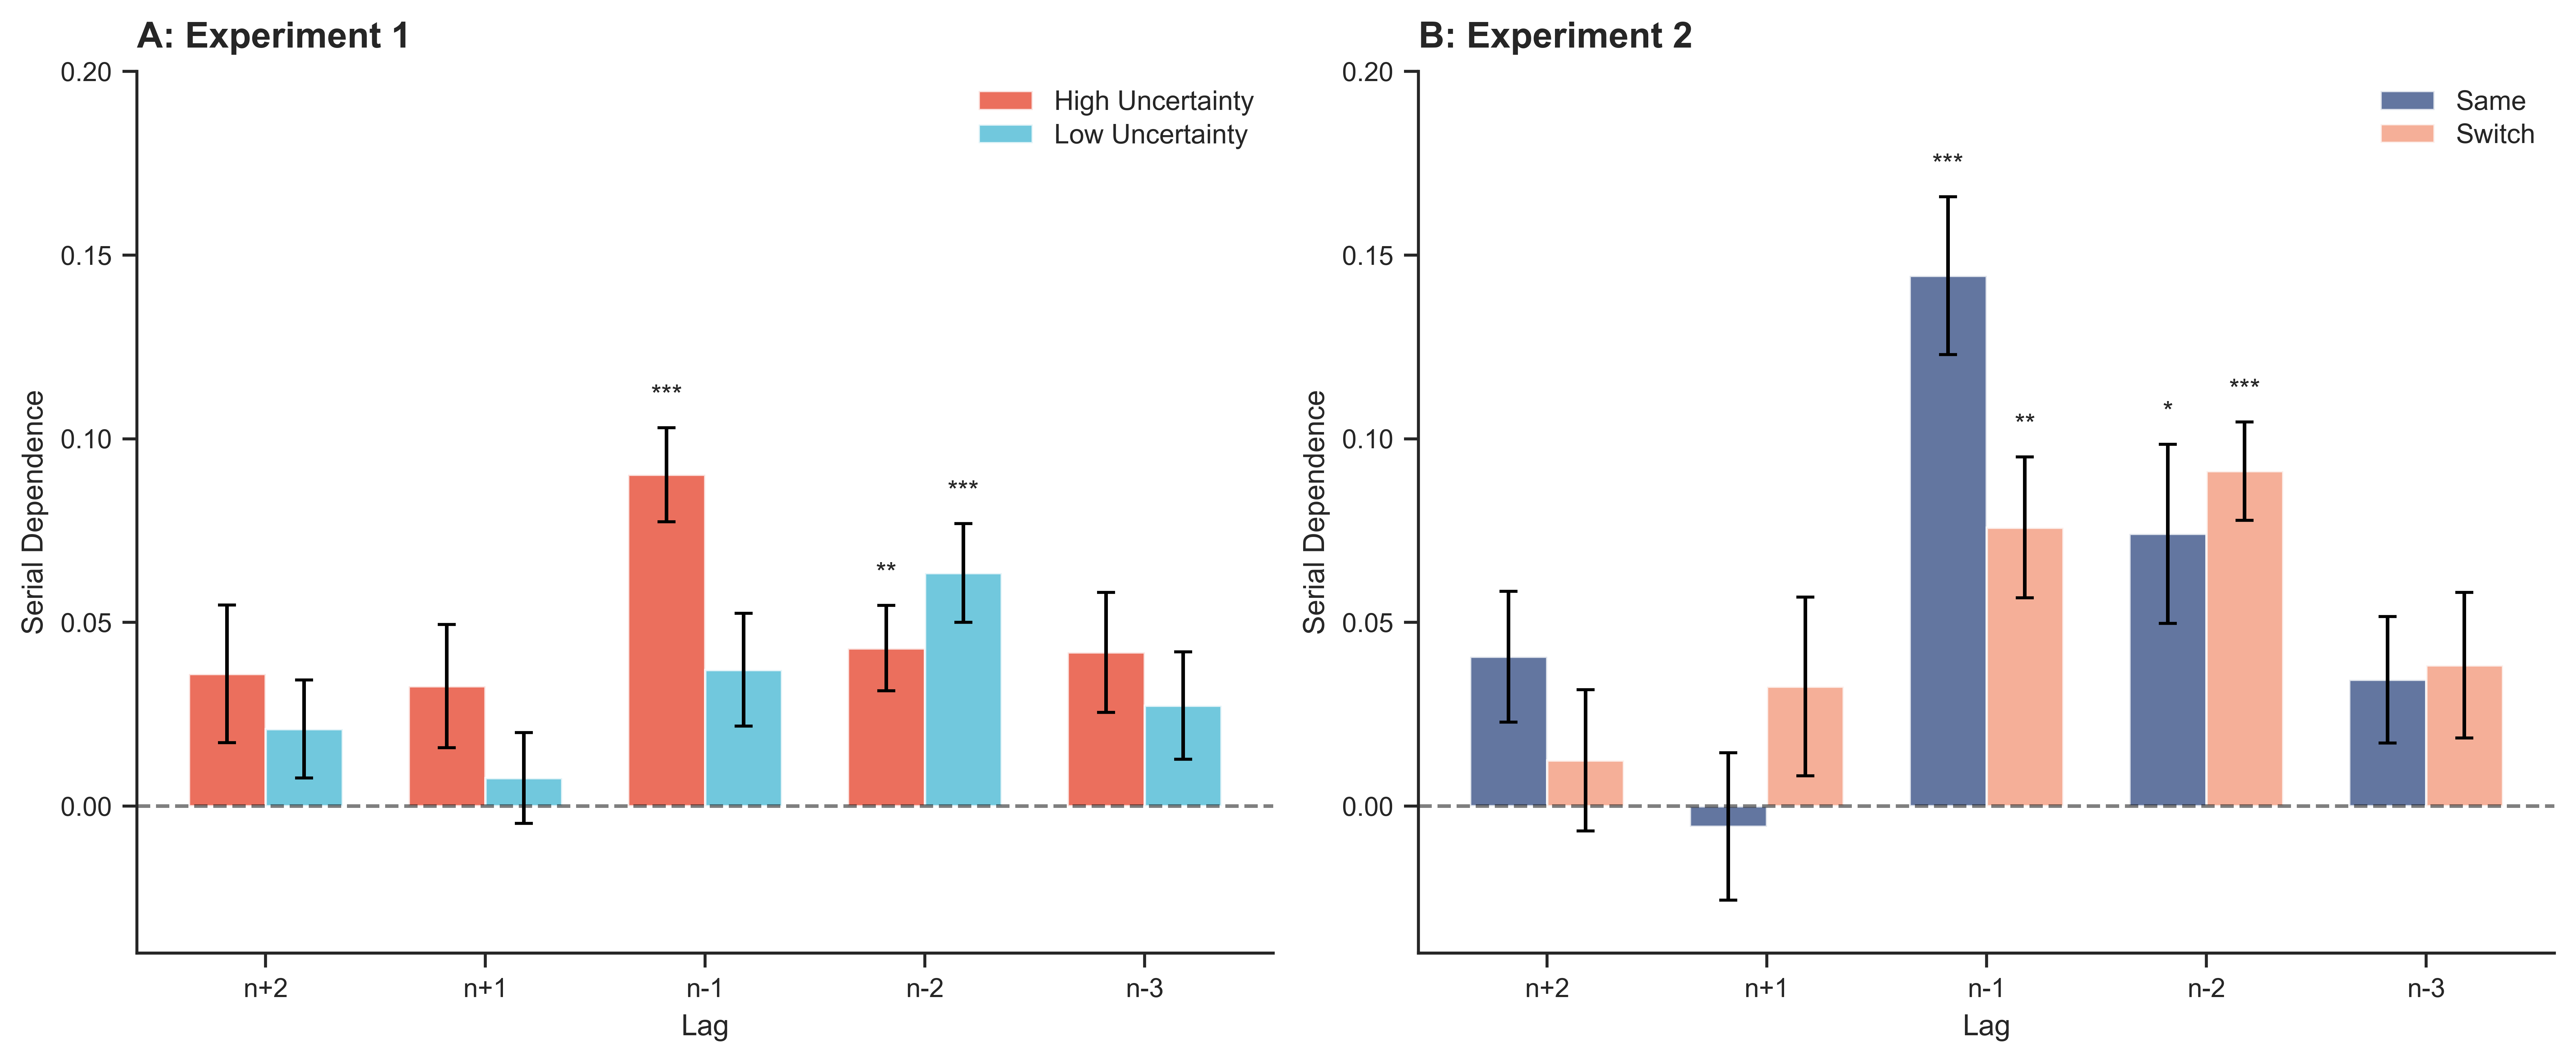

In [17]:
gmf.plot_fig4_sanity_check(df1, df2)
plt.show()

---
## Figure 5: Cross-Experiment Comparison

Panel A: Exp1 Same vs Switch t=1.538, p=0.1389; Exp2 t=4.776, p=0.0001
Panel B: Exp1 High vs Low t=2.866, p=0.0092; Exp2 t=0.559, p=0.5823

Saved fig5_cross_experiment


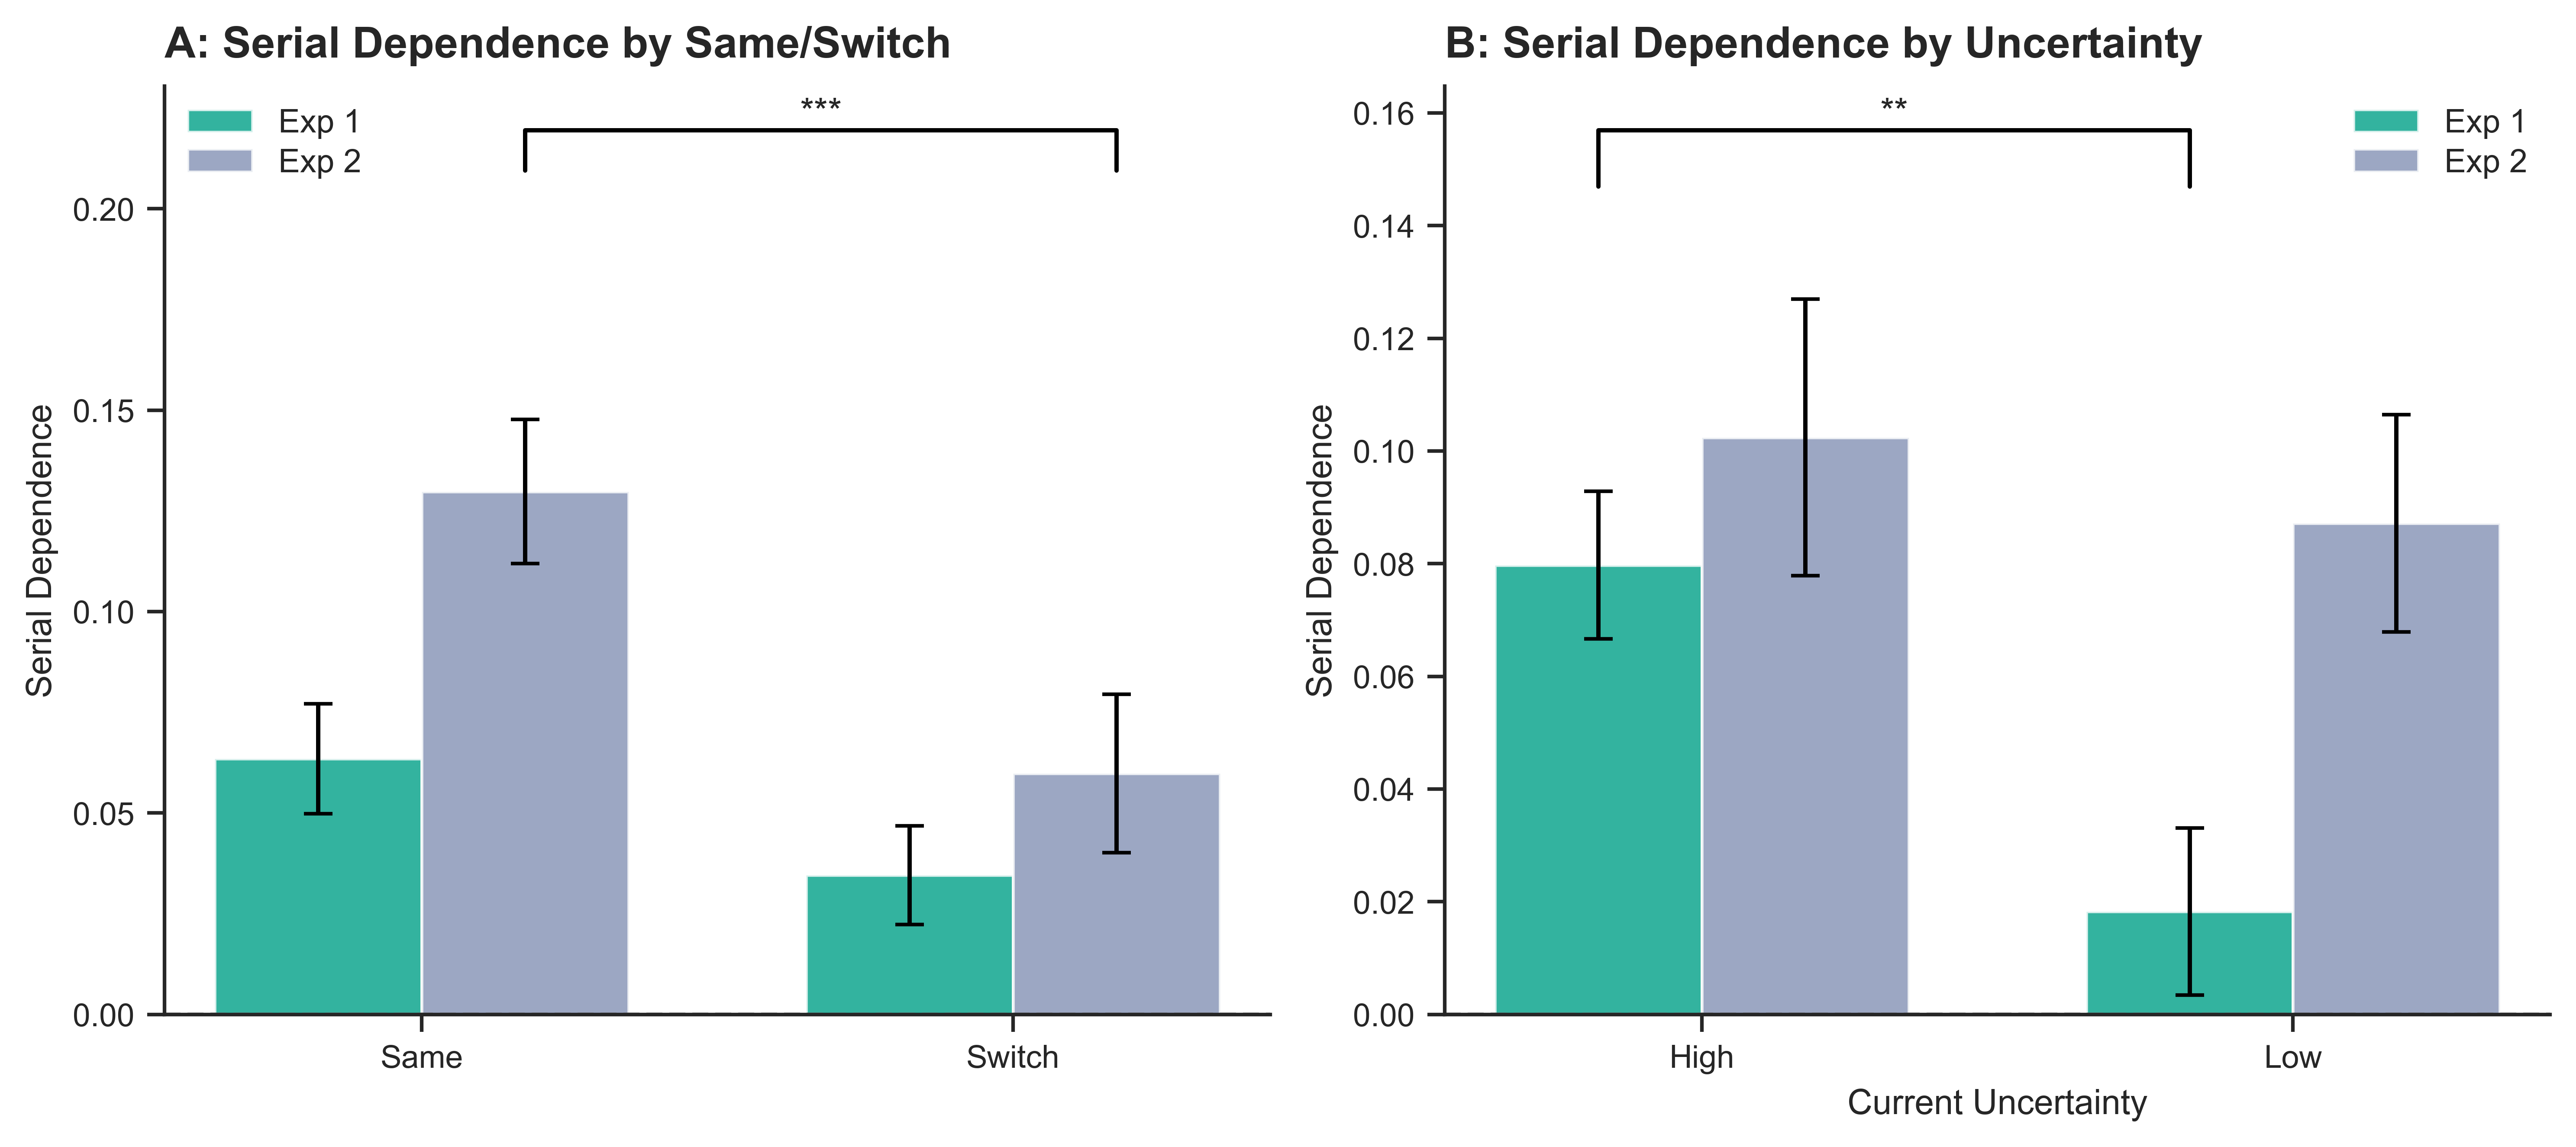

In [18]:
gmf.plot_fig5_cross_experiment(df1, df2, df_sdi_1, df_sdi_2)
plt.show()

---
## Model Figures

The next cells require the Kalman filter model output.  
Run `modeling/1_135Model_ThreeState.ipynb` first to generate `modeling/three_state_kalman/Output_135Model/135model_fits.csv`.

In [19]:
model_info = gmf.load_model_data(df1, df2)
MODEL_LOADED = model_info[0]

if MODEL_LOADED:
    (_, results_df, df_model, best_exp1, best_exp2,
     best_data_1, best_data_2,
     C_AXIS, S_AXIS, B_AXIS,
     get_best_model, rank_models, compare_axes,
     generate_ppc_single_subject) = model_info
    print('Model data loaded successfully.')
else:
    print('Model data not available — skipping model figures.')

Loaded model results: 5940 fits
  Exp1: 2970 fits
  Exp2: 2970 fits

Best models:
  Exp 1: C_Q1__S_baseline__B_B2
  Exp 2: C_Q1__S_x_reset__B_B2
Model data loaded successfully.


---
## Figure C1: Model Comparison

In [20]:
if MODEL_LOADED:
    gmf.plot_figC1_model_comparison(results_df, C_AXIS, S_AXIS, B_AXIS, compare_axes)
    plt.show()
else:
    print('Skipped — model data not loaded.')

Saved figC1_model_comparison


---
## Figure 7: Best-Model Parameters


Best Models Summary:

Experiment 1: C1_S0_B2 (internal: C_Q1__S_baseline__B_B2)
  N subjects: 22
  Key parameters:
    q1: 5.2450 ± 1.3563
    q2: 0.4621 ± 0.3815
    q3: 1.6437 ± 0.4019
    alpha_q1: -0.6025 ± 0.6485
    lambda: 0.4426 ± 0.0815

Experiment 2: C1_S1_B2 (internal: C_Q1__S_x_reset__B_B2)
  N subjects: 22
  Key parameters:
    q1: 2.7252 ± 1.0131
    q2: 0.5627 ± 0.4159
    q3: 0.9441 ± 0.2579
    alpha_q1: -1.8160 ± 0.6567
    lambda: 0.6650 ± 0.0804
    x_reset: 0.4357 ± 0.0838

Saved fig7_parameters


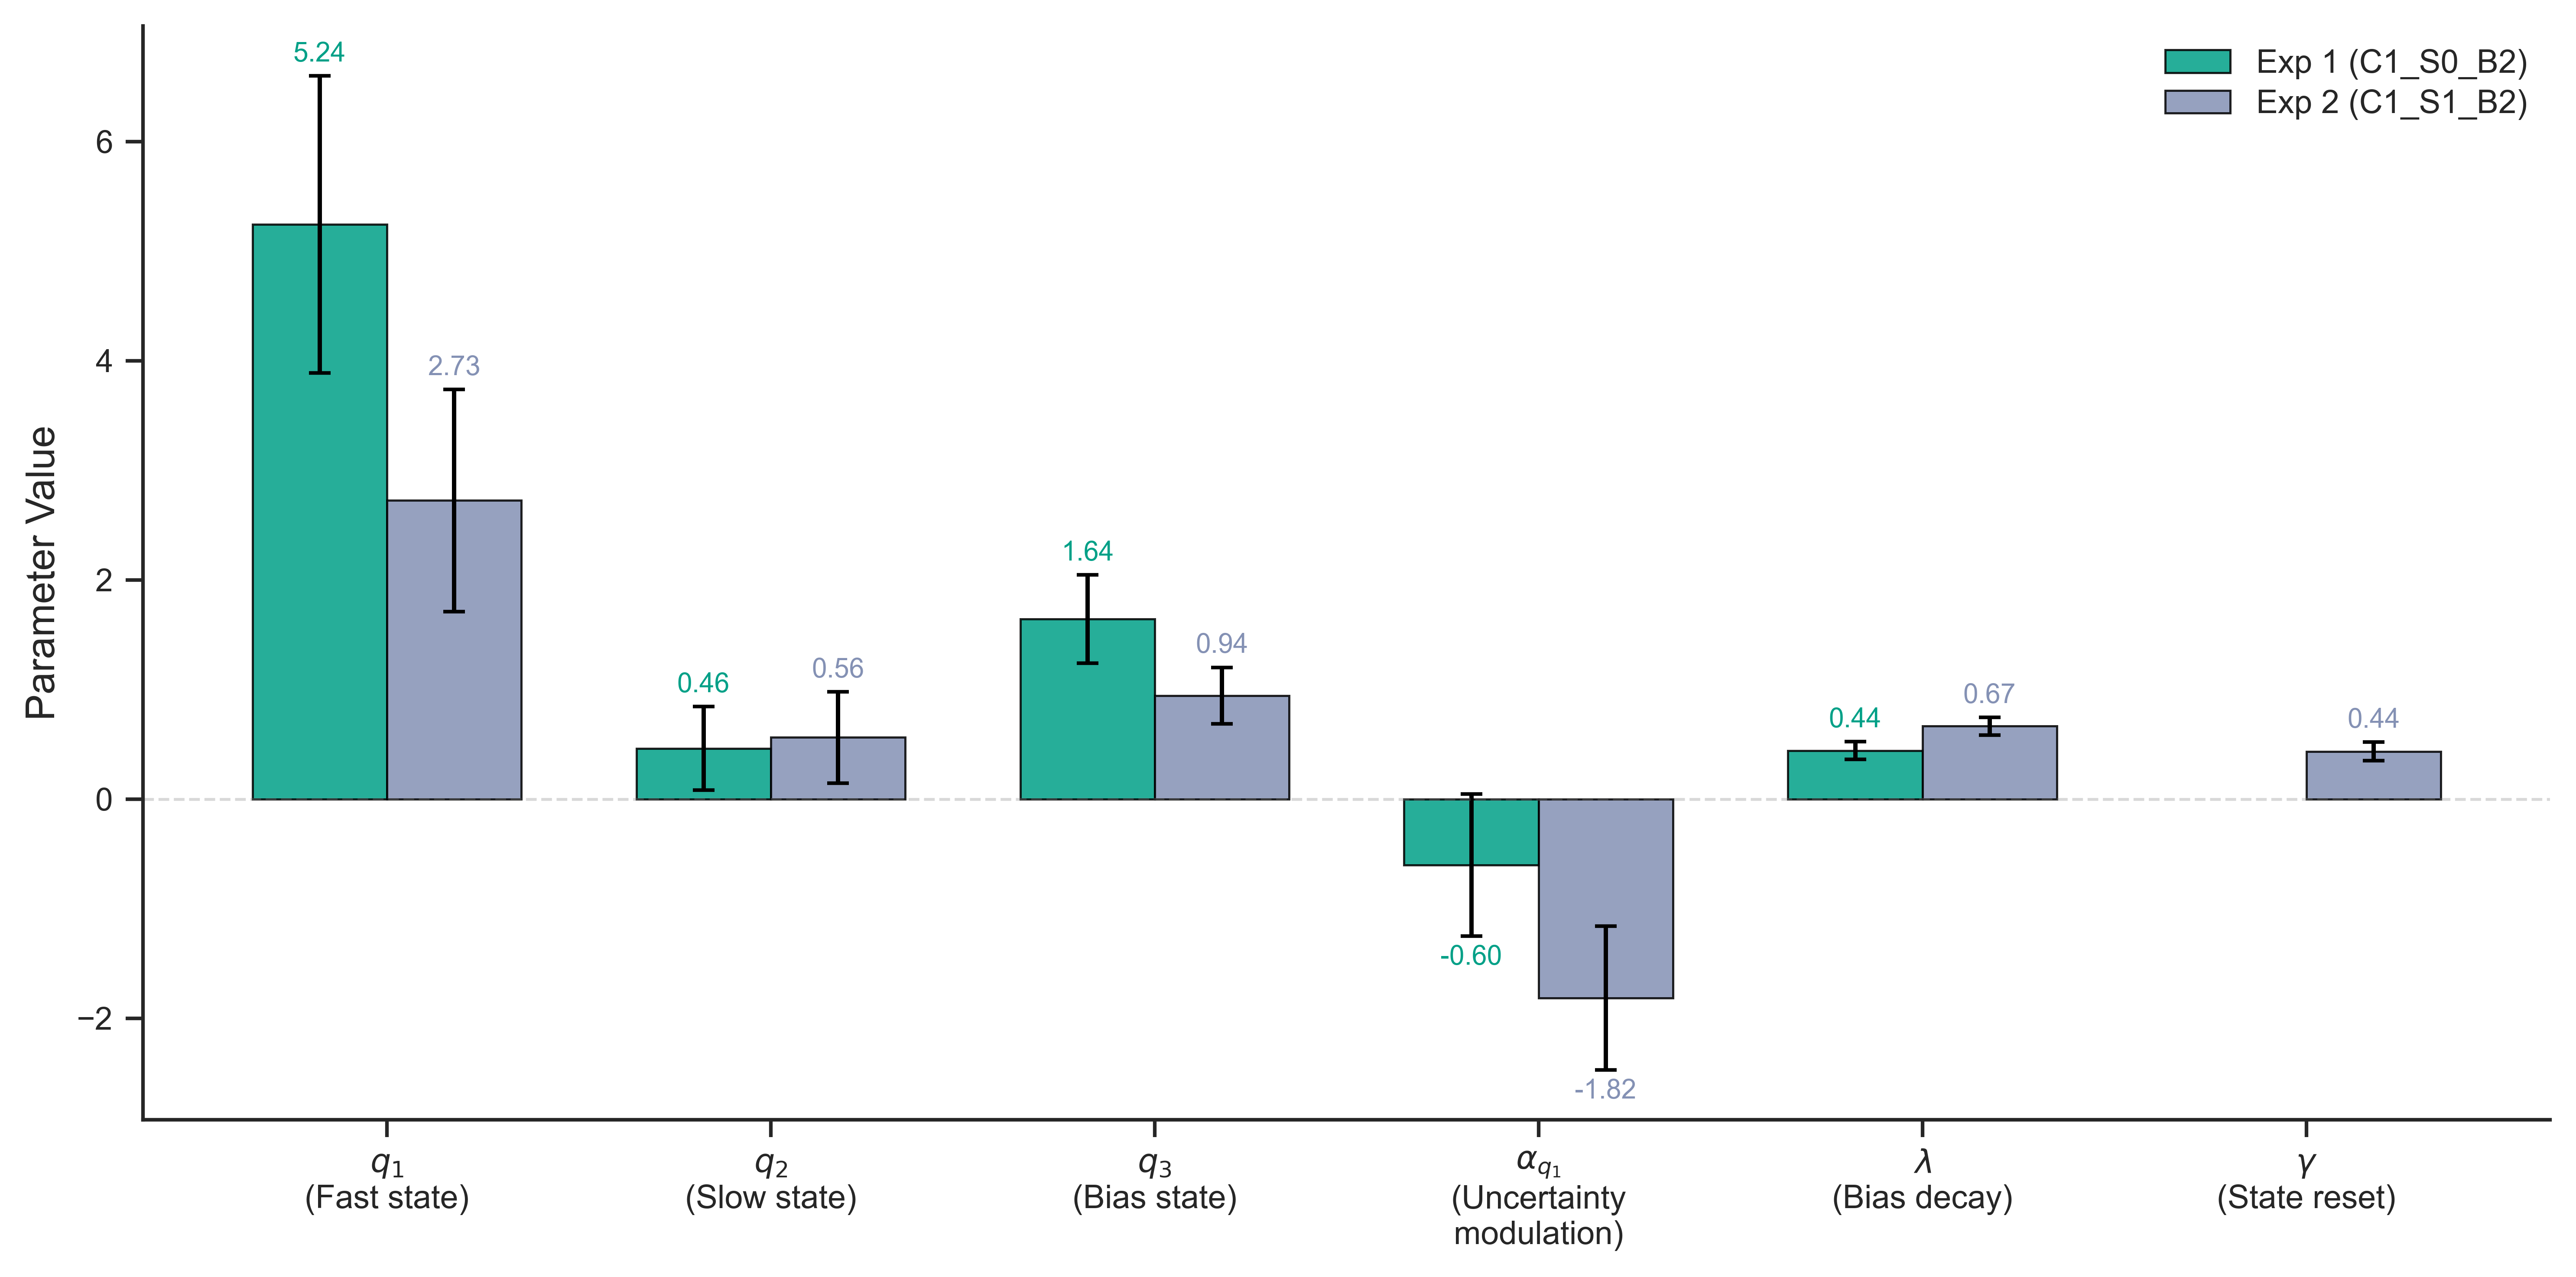

In [21]:
if MODEL_LOADED:
    gmf.plot_fig7_parameters(results_df, get_best_model)
    plt.show()
else:
    print('Skipped — model data not loaded.')

---
## Figure C2: CTI / SDI Recovery (Posterior Predictive Check)

In [22]:
if MODEL_LOADED:
    ppc_results = gmf.plot_figC2_cti_sdi_recovery(
        df_model, results_df, best_exp1, best_exp2,
        generate_ppc_single_subject)
    plt.show()
else:
    print('Skipped — model data not loaded.')

Running PPC for CTI & SDI Recovery...

  Exp 1: C_Q1__S_baseline__B_B2
    CTI: r = 0.996, Recovery = 100%
    SDI: r = 0.867, Recovery = 105%

  Exp 2: C_Q1__S_x_reset__B_B2
    CTI: r = 0.995, Recovery = 98%
    SDI: r = 0.935, Recovery = 104%

Saved figC2_cti_sdi_recovery


---
## Figure 8: Trial-Level Serial Dependence — Model vs. Data

Saved fig8_trial_level_sd


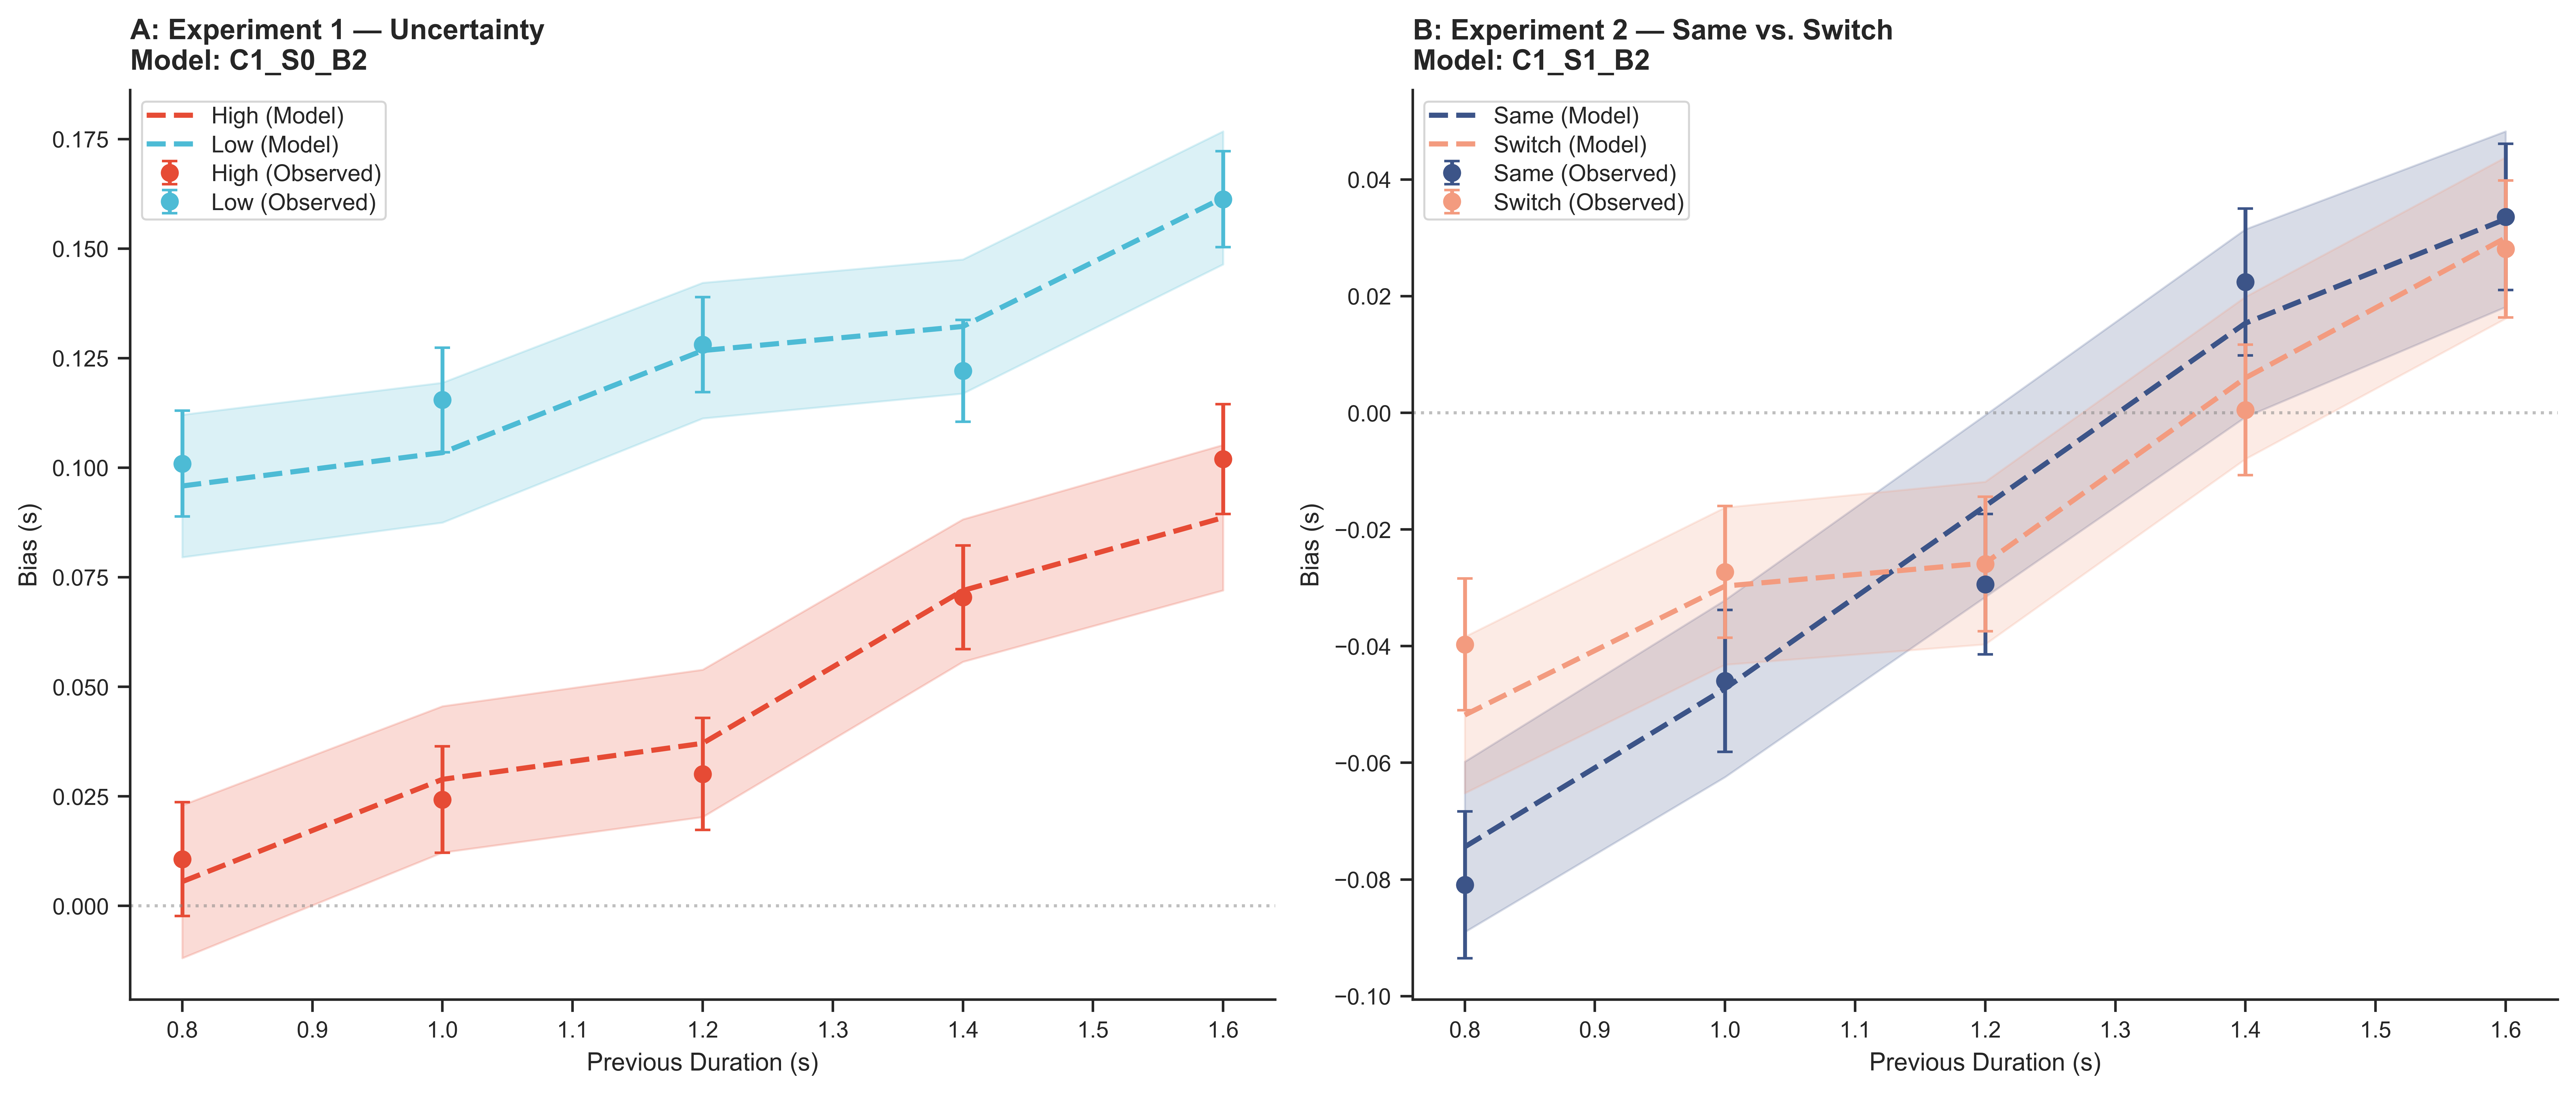

In [23]:
if MODEL_LOADED:
    gmf.plot_fig8_trial_level_sd(
        df_model, results_df, best_exp1, best_exp2,
        generate_ppc_single_subject)
    plt.show()
else:
    print('Skipped — model data not loaded.')

---
All figures saved to `figures/`.